# Memory

AI applications need memory to share context across multiple interactions. In LangGraph, you can add two types of memory:

* Add short-term memory as a part of your agent’s state to enable multi-turn conversations.
* Add long-term memory to store user-specific or application-level data across sessions.

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["ANTHROPIC_API_KEY"] = os.getenv("ANTHROPIC_API_KEY")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

## Add short-term memory

Short-term memory (thread-level persistence) enables agents to track multi-turn conversations. To add short-term memory:

In [2]:
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

model = init_chat_model("gpt-4.1-mini")


# Node
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": response}


builder = StateGraph(MessagesState)

builder.add_node("chat", call_model)
builder.add_edge(START, "chat")

memory = InMemorySaver()

graph = builder.compile(checkpointer=memory)

In [3]:
config = {"configurable": {"thread_id": "1"}}

graph.invoke({"messages": [{"role": "user", "content": "Hi my name is Nitin"}]}, config)

graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config)

{'messages': [HumanMessage(content='Hi my name is Nitin', additional_kwargs={}, response_metadata={}, id='b669e87d-2828-4537-8d7e-b5ec6ebc5fb5'),
  AIMessage(content='Hello Nitin! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 13, 'total_tokens': 24, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_5e793402c9', 'id': 'chatcmpl-DKOLB5hysS5dGCcXvuFyq36oASulZ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cfbe3-32fe-7801-abc9-d86aa4504827-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 11, 'total_tokens': 24, 'input_token_details': {'audio': 0, 'cache_read': 0

### Use in subgraphs

If your graph contains subgraphs, you only need to provide the checkpointer when compiling the parent graph. LangGraph will automatically propagate the checkpointer to the child subgraphs.

In [4]:
from langgraph.graph import START, StateGraph
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict


class State(TypedDict):
    foo: str


# --------------------
# Subgraph
# --------------------


def subgraph_node_1(state: State):
    print("Subgraph node running")
    return {"foo": state["foo"] + "bar"}


subgraph_builder = StateGraph(State)

subgraph_builder.add_node("subgraph_node_1", subgraph_node_1)

subgraph_builder.add_edge(START, "subgraph_node_1")

subgraph = subgraph_builder.compile()


# --------------------
# Parent Graph
# --------------------

builder = StateGraph(State)

builder.add_node("node_1", subgraph)

builder.add_edge(START, "node_1")


checkpointer = InMemorySaver()

graph = builder.compile(checkpointer=checkpointer)


# --------------------
# Run Graph
# --------------------

config = {"configurable": {"thread_id": "thread_1"}}

result = graph.invoke({"foo": "hello"}, config)

print(result)

Subgraph node running
{'foo': 'hellobar'}


## Add long-term memory

Use long-term memory to store user-specific or application-specific data across conversations.

```python
from langgraph.store.memory import InMemoryStore  
from langgraph.graph import StateGraph

store = InMemoryStore()

builder = StateGraph(...)
graph = builder.compile(store=store)
```

### Access the store inside nodes

Once you compile a graph with a store, LangGraph automatically injects the store into your node functions. The recommended way to access the store is through the `Runtime` object.

In [17]:
from dataclasses import dataclass
from langgraph.runtime import Runtime
from langgraph.graph import StateGraph, MessagesState, START
import uuid
from langgraph.store.memory import InMemoryStore


@dataclass
class Context:
    user_id: str


async def call_model(state: MessagesState, runtime: Runtime[Context]):
    user_id = runtime.context.user_id
    namespace = (user_id, "memories")

    memories = await runtime.store.asearch(
        namespace, query=state["messages"][-1].content, limit=3
    )

    info = "\n".join([d.value["data"] for d in memories])
    print("Retrieved memories:", info)

    await runtime.store.aput(
        namespace,
        str(uuid.uuid4()),
        {"data": f"User said: {state['messages'][-1].content}"},
    )

    return {}


store = InMemoryStore()

builder = StateGraph(MessagesState, context_schema=Context)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

graph = builder.compile(store=store)


async def main():
    result = await graph.ainvoke(
        {"messages": [{"role": "user", "content": "hi"}]},
        {"configurable": {"thread_id": "1"}},
        context=Context(user_id="1"),
    )

    print(result)


await main()

Retrieved memories: 
{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='4286aadb-2091-4870-8c26-adca33aabf5e')]}


In [18]:
await graph.ainvoke(
    {"messages": [{"role": "user", "content": "settings"}]},
    {"configurable": {"thread_id": "1"}},
    context=Context(user_id="1"),
)

Retrieved memories: User said: hi


{'messages': [HumanMessage(content='settings', additional_kwargs={}, response_metadata={}, id='087202f6-91dd-4604-8036-07c9550dbcb9')]}

In [19]:
await graph.ainvoke(
    {"messages": [{"role": "user", "content": "I like pizza"}]},
    {"configurable": {"thread_id": "1"}},
    context=Context(user_id="1"),
)

await graph.ainvoke(
    {"messages": [{"role": "user", "content": "I like cricket"}]},
    {"configurable": {"thread_id": "1"}},
    context=Context(user_id="1"),
)

Retrieved memories: User said: hi
User said: settings
Retrieved memories: User said: hi
User said: settings
User said: I like pizza


{'messages': [HumanMessage(content='I like cricket', additional_kwargs={}, response_metadata={}, id='a0cc34a1-228a-4538-8f6c-31ed98dbcc2f')]}

In [20]:
await graph.ainvoke(
    {"messages": [{"role": "user", "content": "I like coffee"}]},
    {"configurable": {"thread_id": "1"}},
    context=Context(user_id="1"),
)

Retrieved memories: User said: hi
User said: settings
User said: I like pizza


{'messages': [HumanMessage(content='I like coffee', additional_kwargs={}, response_metadata={}, id='faa6989e-4e7e-4a34-beaa-a2a4d6d1f6c4')]}

In [21]:
memories = await store.asearch(("1", "memories"), query="hi", limit=10)

for m in memories:
    print(m.value)

{'data': 'User said: hi'}
{'data': 'User said: settings'}
{'data': 'User said: I like pizza'}
{'data': 'User said: I like cricket'}
{'data': 'User said: I like coffee'}


### Use semantic search

Enable semantic search in your graph’s memory store to let graph agents search for items in the store by semantic similarity.

In [23]:
from langchain.embeddings import init_embeddings
from langchain.chat_models import init_chat_model
from langgraph.store.memory import InMemoryStore
from langgraph.graph import START, MessagesState, StateGraph
from langgraph.runtime import Runtime

model = init_chat_model("gpt-4.1-mini")

# Create store with semantic search enabled
embeddings = init_embeddings("openai:text-embedding-3-small")
store = InMemoryStore(
    index={
        "embed": embeddings,
        "dims": 1536,
    }
)

store.put(("user_123", "memories"), "1", {"text": "I love pizza"})
store.put(("user_123", "memories"), "2", {"text": "I am a plumber"})


async def chat(state: MessagesState, runtime: Runtime):
    # Search based on user's last message
    items = await runtime.store.asearch(
        ("user_123", "memories"), query=state["messages"][-1].content, limit=2
    )
    memories = "\n".join(item.value["text"] for item in items)
    memories = f"## Memories of user\n{memories}" if memories else ""
    response = await model.ainvoke(
        [
            {"role": "system", "content": f"You are a helpful assistant.\n{memories}"},
            *state["messages"],
        ]
    )
    return {"messages": [response]}


builder = StateGraph(MessagesState)
builder.add_node(chat)
builder.add_edge(START, "chat")
graph = builder.compile(store=store)

async for message, metadata in graph.astream(
    input={"messages": [{"role": "user", "content": "I'm hungry"}]},
    stream_mode="messages",
):
    print(message.content, end="")

Since you love pizza, how about ordering or making a delicious pizza to satisfy your hunger? If you'd like, I can help you find a great pizza recipe or suggest some popular toppings!

## Manage short-term memory

With short-term memory enabled, long conversations can exceed the LLM’s context window. Common solutions are:

* Trim messages: Remove first or last N messages (before calling LLM)
* Delete messages from LangGraph state permanently
* Summarize messages: Summarize earlier messages in the history and replace them with a summary
* Manage checkpoints to store and retrieve message history
* Custom strategies (e.g., message filtering, etc.)
This allows the agent to keep track of the conversation without exceeding the LLM’s context window.

### Trim messages

Most LLMs have a maximum supported context window (denominated in tokens). One way to decide when to truncate messages is to count the tokens in the message history and truncate whenever it approaches that limit. If you’re using LangChain, you can use the trim messages utility and specify the number of tokens to keep from the list, as well as the strategy (e.g., keep the last max_tokens) to use for handling the boundary.
To trim message history, use the trim_messages function:

In [28]:
from langchain_core.messages.utils import trim_messages, count_tokens_approximately
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, MessagesState

model = init_chat_model("claude-sonnet-4-6")
summarization_model = model.bind(max_tokens=128)


def call_model(state: MessagesState):
    messages = trim_messages(
        state["messages"],
        strategy="last",
        token_counter=count_tokens_approximately,
        max_tokens=128,
        start_on="human",
        end_on=("human", "tool"),
    )
    response = model.invoke(messages)
    return {"messages": [response]}


checkpointer = InMemorySaver()
builder = StateGraph(MessagesState)
builder.add_node(call_model)
builder.add_edge(START, "call_model")
graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "1"}}
graph.invoke({"messages": "hi, my name is bob"}, config)
graph.invoke({"messages": "write a short poem about cats"}, config)
graph.invoke({"messages": "now do the same but for dogs"}, config)
final_response = graph.invoke({"messages": "what's my name?"}, config)

final_response["messages"][-1].pretty_print()

================================== Ai Message ==================================

I don't know your name! I don't have access to any personal information about you unless you share it with me. What's your name? 😊


### Delete messages

You can delete messages from the graph state to manage the message history. This is useful when you want to remove specific messages or clear the entire message history.

To delete messages from the graph state, you can use the `RemoveMessage`. For `RemoveMessage` to work, you need to use a state key with `add_messages` reducer, like `MessagesState`.
To remove specific messages:

In [29]:
from langchain.messages import RemoveMessage


def delete_messages(state):
    messages = state["messages"]
    if len(messages) > 2:
        # remove the earliest two messages
        return {"messages": [RemoveMessage(id=m.id) for m in messages[:2]]}


def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": response}


builder = StateGraph(MessagesState)
builder.add_sequence([call_model, delete_messages])
builder.add_edge(START, "call_model")

checkpointer = InMemorySaver()
app = builder.compile(checkpointer=checkpointer)

for event in app.stream(
    {"messages": [{"role": "user", "content": "hi! I'm bob"}]},
    config,
    stream_mode="values",
):
    print([(message.type, message.content) for message in event["messages"]])

for event in app.stream(
    {"messages": [{"role": "user", "content": "what's my name?"}]},
    config,
    stream_mode="values",
):
    print([(message.type, message.content) for message in event["messages"]])

[('human', "hi! I'm bob")]
[('human', "hi! I'm bob"), ('ai', 'Hi Bob! Nice to meet you. How can I help you today? 😊')]
[('human', "hi! I'm bob"), ('ai', 'Hi Bob! Nice to meet you. How can I help you today? 😊'), ('human', "what's my name?")]
[('human', "hi! I'm bob"), ('ai', 'Hi Bob! Nice to meet you. How can I help you today? 😊'), ('human', "what's my name?"), ('ai', 'Your name is Bob! You told me at the start of our conversation. 😊')]
[('human', "what's my name?"), ('ai', 'Your name is Bob! You told me at the start of our conversation. 😊')]


### Summarize messages

The problem with trimming or removing messages, as shown above, is that you may lose information from culling of the message queue. Because of this, some applications benefit from a more sophisticated approach of summarizing the message history using a chat model.

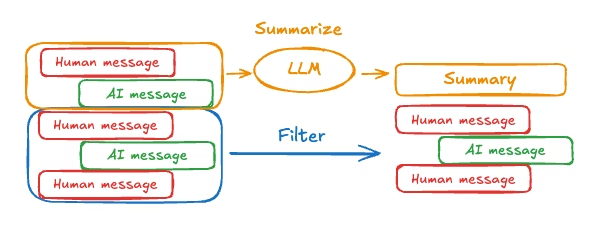

In [34]:
from typing import Any, TypedDict

from langchain.chat_models import init_chat_model
from langchain.messages import AnyMessage
from langchain_core.messages.utils import count_tokens_approximately
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langmem.short_term import SummarizationNode, RunningSummary

model = init_chat_model("claude-sonnet-4-6")
summarization_model = model.bind(max_tokens=128)


class State(MessagesState):
    context: dict[str, RunningSummary]


class LLMInputState(TypedDict):
    summarized_messages: list[AnyMessage]
    context: dict[str, RunningSummary]


summarization_node = SummarizationNode(
    token_counter=count_tokens_approximately,
    model=summarization_model,
    max_tokens=256,
    max_tokens_before_summary=256,
    max_summary_tokens=128,
)


def call_model(state: LLMInputState):
    response = model.invoke(state["summarized_messages"])
    return {"messages": [response]}


checkpointer = InMemorySaver()
builder = StateGraph(State)
builder.add_node(call_model)
builder.add_node("summarize", summarization_node)
builder.add_edge(START, "summarize")
builder.add_edge("summarize", "call_model")
graph = builder.compile(checkpointer=checkpointer)

# Invoke the graph
config = {"configurable": {"thread_id": "1"}}

graph.invoke({"messages": [{"role": "user", "content": "hi, my name is bob"}]}, config)

graph.invoke(
    {"messages": [{"role": "user", "content": "write a short poem about cats"}]}, config
)

graph.invoke(
    {"messages": [{"role": "user", "content": "now do the same but for dogs"}]}, config
)

final_response = graph.invoke(
    {"messages": [{"role": "user", "content": "what's my name?"}]},
    config,
    output_keys=None,
)

final_response["messages"][-1].pretty_print()

print("\nSummary:", final_response["context"]["running_summary"].summary)

================================== Ai Message ==================================

Your name is Bob! You told me at the beginning of our conversation. 😊


KeyError: 'context'